In [1]:
!pip install mongita

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 17.4 MB/s eta 0:00:00
  Created wheel for mongita: filename=mongita-1.2.0-py3-none-any.whl size=61258 sha256=4b477782be5ea9f1f007662d25fc879baa032b9a1bd0728ee25b19b25340ab77
  Stored in directory: /root/.cache/pip/wheels/c0/bf/0d/6a2a625c704f15045f2e0286f8a819f2104eeaefb92cd42a4f
Successfully built mongita


In [2]:
from mongita import MongitaClientDisk

client = MongitaClientDisk()
db = client["northstar_db"]

orders = db["orders"]

print("MongoDB ready ✔")

MongoDB ready ✔


Orders Collection: Centtral "Case" Document

In [3]:
order_doc = {
  "_id": "O123456789",
  "customerId": "C98765",
  "driverId": "D4321",
  "hubId": "H01",
  "zone": "North Zone",
  "serviceType": "LastMileDelivery",
  "status": "Completed",

  "times": {
    "orderCreated": "2026-03-01T08:15:00Z",
    "scheduledPickup": "2026-03-01T09:00:00Z",
    "dispatched": "2026-03-01T08:45:00Z",
    "arrivedAtHub": "2026-03-01T09:20:00Z",
    "outForDelivery": "2026-03-01T09:40:00Z",
    "delivered": "2026-03-01T10:05:00Z",
    "windowStart": "2026-03-01T09:30:00Z",
    "windowEnd": "2026-03-01T10:00:00Z"
  },

  "sla": {
    "deliveryWindowMinutes": 30,
    "met": False,
    "lateMinutes": 5
  },

  "metrics": {
    "deliveryTimeHours": 1.83,
    "lateFlag": True,
    "unfulfilledFlag": False,
    "anomalyFlag": True,
    "cost": 7.50,
    "revenue": 9.00,
    "margin": 1.50
  },

  "route": {
    "plannedRouteId": "R567",
    "manualOverrides": 2,
    "gpsPath": [
      {"lat": 51.5001, "lon": -0.1234, "ts": "2026-03-01T09:00:00Z"},
      {"lat": 51.5020, "lon": -0.1200, "ts": "2026-03-01T09:05:00Z"}
    ]
  },

  "events": [
    {
      "eventType": "APP_BOOKING",
      "timestamp": "2026-03-01T08:15:00Z",
      "actor": "CUSTOMER",
      "channel": "MOBILE_APP",
      "details": {
        "pickupLocation": "Station A",
        "dropoffLocation": "Customer Address",
        "paymentMethod": "Card"
      }
    },
    {
      "eventType": "ROUTE_OVERRIDE",
      "timestamp": "2026-03-01T09:30:00Z",
      "actor": "DRIVER",
      "details": {
        "reason": "Road closure",
        "fromRouteSegment": "SEG12",
        "toRouteSegment": "SEG19"
      }
    },
    {
      "eventType": "DELIVERY_CONFIRMED",
      "timestamp": "2026-03-01T10:05:00Z",
      "actor": "DRIVER",
      "details": {
        "proofType": "PHOTO",
        "recipientName": "Smith"
      }
    }
  ],

  "complaints": [
    {
      "complaintId": "COMP-001",
      "timestamp": "2026-03-01T10:30:00Z",
      "channel": "APP",
      "categoryRaw": "Late delivery and poor communication",
      "categoryGroup": "Delay",
      "description": "Parcel arrived late and tracking did not update.",
      "resolutionStatus": "Open",
      "resolutionActions": [
        {
          "timestamp": "2026-03-01T11:00:00Z",
          "actor": "AGENT",
          "actionType": "CREDIT_OFFERED",
          "details": {"amount": 5.00}
        }
      ]
    }
  ],

  "incidents": [
    {
      "incidentId": "INC-101",
      "timestamp": "2026-03-01T09:50:00Z",
      "reportedBy": "DRIVER",
      "typeRaw": "Vehicle breakdown on route",
      "severity": "High",
      "location": {"lat": 51.5030, "lon": -0.1180},
      "notes": "Engine warning, had to stop for 15 minutes."
    }
  ],

  "platformFlags": {
    "exceptionCode": "EX_DELIVER_LATE",
    "sensorAlerts": [
      {
        "type": "TYRE_PRESSURE",
        "level": "Warning",
        "timestamp": "2026-03-01T09:40:00Z"
      }
    ]
  }
}

In [4]:
orders.insert_one(order_doc)

print("Order inserted ✔")

Order inserted ✔


In [5]:
orders.find_one({"_id": "O123456789"})

{'_id': 'O123456789',
 'customerId': 'C98765',
 'driverId': 'D4321',
 'hubId': 'H01',
 'zone': 'North Zone',
 'serviceType': 'LastMileDelivery',
 'status': 'Completed',
 'times': {'orderCreated': '2026-03-01T08:15:00Z',
  'scheduledPickup': '2026-03-01T09:00:00Z',
  'dispatched': '2026-03-01T08:45:00Z',
  'arrivedAtHub': '2026-03-01T09:20:00Z',
  'outForDelivery': '2026-03-01T09:40:00Z',
  'delivered': '2026-03-01T10:05:00Z',
  'windowStart': '2026-03-01T09:30:00Z',
  'windowEnd': '2026-03-01T10:00:00Z'},
 'sla': {'deliveryWindowMinutes': 30, 'met': False, 'lateMinutes': 5},
 'metrics': {'deliveryTimeHours': 1.83,
  'lateFlag': True,
  'unfulfilledFlag': False,
  'anomalyFlag': True,
  'cost': 7.5,
  'revenue': 9.0,
  'margin': 1.5},
 'route': {'plannedRouteId': 'R567',
  'manualOverrides': 2,
  'gpsPath': [{'lat': 51.5001, 'lon': -0.1234, 'ts': '2026-03-01T09:00:00Z'},
   {'lat': 51.502, 'lon': -0.12, 'ts': '2026-03-01T09:05:00Z'}]},
 'events': [{'eventType': 'APP_BOOKING',
   'timest

Customer Collection

In [10]:
from mongita import MongitaClientDisk

client = MongitaClientDisk()
db = client["northstar_db"]

In [11]:
customers = db["customers"]

In [12]:
customers.insert_one({
  "_id": "C98765",
  "name": "ACME Logistics Ltd",
  "type": "Business",
  "contact": {
    "email": "ops@acme.com",
    "phone": "+44 20 1234 5678"
  },
  "locations": [
    { "label": "HQ", "city": "London", "zone": "Central Zone" },
    { "label": "Warehouse", "city": "London", "zone": "North Zone" }
  ],
  "metrics": {
    "totalOrders": 312,
    "totalComplaints": 18,
    "repeatComplaintCustomers": 5,
    "avgOnTimeRate": 0.91
  },
  "lastOrderAt": "2026-03-01T10:05:00Z"
})

In [13]:
customers.find_one({"_id": "C98765"})

{'_id': 'C98765',
 'name': 'ACME Logistics Ltd',
 'type': 'Business',
 'contact': {'email': 'ops@acme.com', 'phone': '+44 20 1234 5678'},
 'locations': [{'label': 'HQ', 'city': 'London', 'zone': 'Central Zone'},
  {'label': 'Warehouse', 'city': 'London', 'zone': 'North Zone'}],
 'metrics': {'totalOrders': 312,
  'totalComplaints': 18,
  'repeatComplaintCustomers': 5,
  'avgOnTimeRate': 0.91},
 'lastOrderAt': '2026-03-01T10:05:00Z'}

Drivers Collection

In [14]:
from mongita import MongitaClientDisk

client = MongitaClientDisk()
db = client["northstar_db"]

drivers = db["drivers"]

In [15]:
drivers.insert_one({
  "_id": "D4321",
  "name": "Jane Doe",
  "hireDate": "2022-07-15",
  "homeHubId": "H01",
  "homeZone": "North Zone",

  "currentStatus": "Active",
  "licenses": ["B", "C1"],
  "vehicleIds": ["V-1001"],

  "performance": {
    "totalDeliveries": 1832,
    "onTimeRate": 0.88,
    "unfulfilledOrders": 45,
    "anomalyRate": 0.07,
    "complaintsLinked": 32,
    "incidentsTotal": 9,
    "highSeverityIncidents": 3
  }
})

In [16]:
drivers.find_one({"_id": "D4321"})

{'_id': 'D4321',
 'name': 'Jane Doe',
 'hireDate': '2022-07-15',
 'homeHubId': 'H01',
 'homeZone': 'North Zone',
 'currentStatus': 'Active',
 'licenses': ['B', 'C1'],
 'vehicleIds': ['V-1001'],
 'performance': {'totalDeliveries': 1832,
  'onTimeRate': 0.88,
  'unfulfilledOrders': 45,
  'anomalyRate': 0.07,
  'complaintsLinked': 32,
  'incidentsTotal': 9,
  'highSeverityIncidents': 3}}

Hubs / Zones Collection

In [17]:
from mongita import MongitaClientDisk

client = MongitaClientDisk()
db = client["northstar_db"]

hubs = db["hubs"]

In [18]:
hubs.insert_one({
  "_id": "H01",
  "name": "North City Hub",
  "zone": "North Zone",
  "city": "Manchester",
  "type": "Warehouse",
  "capacity": {
    "docks": 18,
    "chargingPoints": 24
  },
  "metrics": {
    "avgDispatchPerDay": 950,
    "avgOnTimeRate": 0.84,
    "avgComplaintRatePer100": 4.5
  }
})

In [19]:
hubs.find_one({"_id": "H01"})

{'_id': 'H01',
 'name': 'North City Hub',
 'zone': 'North Zone',
 'city': 'Manchester',
 'type': 'Warehouse',
 'capacity': {'docks': 18, 'chargingPoints': 24},
 'metrics': {'avgDispatchPerDay': 950,
  'avgOnTimeRate': 0.84,
  'avgComplaintRatePer100': 4.5}}

In [21]:
import pandas as pd

# Load all orders from mongita
orders_data = list(orders.find())

# Convert to dataframe
orders_df = pd.DataFrame(orders_data)

orders_df.head()

,_id,customerId,driverId,hubId,zone,serviceType,status,times,sla,metrics,route,events,complaints,incidents,platformFlags
0,O123456789,C98765,D4321,H01,North Zone,LastMileDelivery,Completed,"{'orderCreated': '2026-03-01T08:15:00Z', 'sche...","{'deliveryWindowMinutes': 30, 'met': False, 'l...","{'deliveryTimeHours': 1.83, 'lateFlag': True, ...","{'plannedRouteId': 'R567', 'manualOverrides': ...","[{'eventType': 'APP_BOOKING', 'timestamp': '20...","[{'complaintId': 'COMP-001', 'timestamp': '202...","[{'incidentId': 'INC-101', 'timestamp': '2026-...","{'exceptionCode': 'EX_DELIVER_LATE', 'sensorAl..."


In [22]:
metrics_df = pd.json_normalize(orders_df["metrics"])

orders_flat = pd.concat(
    [orders_df.drop(columns=["metrics"]), metrics_df],
    axis=1
)

orders_flat.head()

,_id,customerId,driverId,hubId,zone,serviceType,status,times,sla,route,...,complaints,incidents,platformFlags,deliveryTimeHours,lateFlag,unfulfilledFlag,anomalyFlag,cost,revenue,margin
0,O123456789,C98765,D4321,H01,North Zone,LastMileDelivery,Completed,"{'orderCreated': '2026-03-01T08:15:00Z', 'sche...","{'deliveryWindowMinutes': 30, 'met': False, 'l...","{'plannedRouteId': 'R567', 'manualOverrides': ...",...,"[{'complaintId': 'COMP-001', 'timestamp': '202...","[{'incidentId': 'INC-101', 'timestamp': '2026-...","{'exceptionCode': 'EX_DELIVER_LATE', 'sensorAl...",1.83,True,False,True,7.5,9.0,1.5


In [23]:
zone_perf = (
    orders_flat
    .groupby("zone")
    .agg(
        totalOrders=("_id", "count"),
        unfulfilled=("unfulfilledFlag", "sum"),
        late=("lateFlag", "sum")
    )
    .reset_index()
)

# Percentages
zone_perf["unfulfilledPct"] = (
    zone_perf["unfulfilled"] / zone_perf["totalOrders"] * 100
)

zone_perf

,zone,totalOrders,unfulfilled,late,unfulfilledPct
0,North Zone,1,0,1,0.0


In [24]:
orders_flat["hasComplaint"] = orders_flat["complaints"].apply(
    lambda x: 1 if isinstance(x, list) and len(x) > 0 else 0
)

complaints_zone = (
    orders_flat.groupby("zone")["hasComplaint"]
    .sum()
    .reset_index(name="complaints")
)

zone_perf = zone_perf.merge(complaints_zone, on="zone")

zone_perf["complaintsPer100"] = (
    zone_perf["complaints"] / zone_perf["totalOrders"] * 100
)

zone_perf

,zone,totalOrders,unfulfilled,late,unfulfilledPct,complaints,complaintsPer100
0,North Zone,1,0,1,0.0,1,100.0


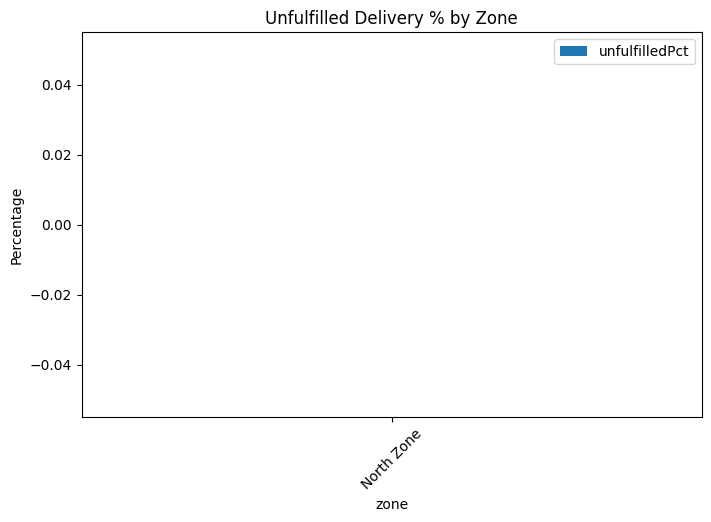

In [25]:
import matplotlib.pyplot as plt

zone_perf.sort_values("unfulfilledPct", ascending=False).plot(
    x="zone",
    y="unfulfilledPct",
    kind="bar",
    figsize=(8,5)
)

plt.title("Unfulfilled Delivery % by Zone")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [26]:
import pandas as pd

# Load all orders
orders_data = list(orders.find())

# Convert to DataFrame
orders_df = pd.DataFrame(orders_data)

# Flatten metrics
metrics_df = pd.json_normalize(orders_df["metrics"])

# Combine
orders_flat = pd.concat(
    [orders_df.drop(columns=["metrics"]), metrics_df],
    axis=1
)

# -------------------------
# Incident calculations
# -------------------------

# total incidents
orders_flat["incidentsTotal"] = orders_flat["incidents"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# high severity incidents
orders_flat["highSeverityIncidents"] = orders_flat["incidents"].apply(
    lambda x: sum(1 for i in x if i.get("severity") == "High")
    if isinstance(x, list) else 0
)

# -------------------------
# Driver analytics
# -------------------------

driver_perf = (
    orders_flat
    .groupby("driverId")
    .agg(
        totalOrders=("_id", "count"),
        lateOrders=("lateFlag", "sum"),
        unfulfilled=("unfulfilledFlag", "sum"),
        incidentsTotal=("incidentsTotal", "sum"),
        highSeverityIncidents=("highSeverityIncidents", "sum")
    )
    .reset_index()
)

# Late %
driver_perf["lateRatePct"] = (
    driver_perf["lateOrders"] /
    driver_perf["totalOrders"] * 100
)

# Sort
driver_perf = driver_perf.sort_values(
    ["lateRatePct", "highSeverityIncidents"],
    ascending=False
)

driver_perf

,driverId,totalOrders,lateOrders,unfulfilled,incidentsTotal,highSeverityIncidents,lateRatePct
0,D4321,1,1,0,1,1,100.0


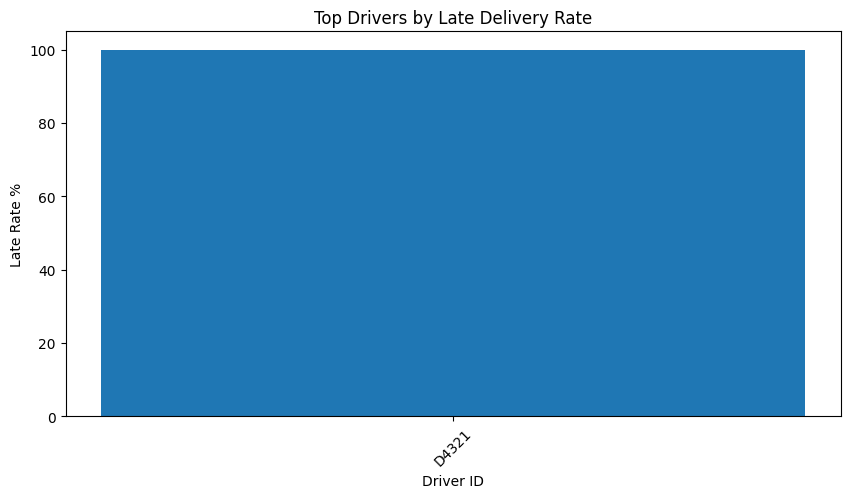

In [27]:
import matplotlib.pyplot as plt

top_drivers = driver_perf.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_drivers["driverId"], top_drivers["lateRatePct"])

plt.title("Top Drivers by Late Delivery Rate")
plt.xlabel("Driver ID")
plt.ylabel("Late Rate %")

plt.xticks(rotation=45)

plt.show()

In [29]:
import pandas as pd

# Load orders from mongita
orders_data = list(orders.find())

# Convert to DataFrame
orders_df = pd.DataFrame(orders_data)

# Flatten metrics
metrics_df = pd.json_normalize(orders_df["metrics"])

orders_flat = pd.concat(
    [orders_df.drop(columns=["metrics"]), metrics_df],
    axis=1
)

# -----------------------------
# Incident count
# -----------------------------
orders_flat["incidentCount"] = orders_flat["incidents"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# -----------------------------
# Filter conditions
# -----------------------------
incident_but_success = orders_flat[
    (orders_flat["incidentCount"] > 0) &
    (orders_flat["lateFlag"] == False) &
    (orders_flat["unfulfilledFlag"] == False)
]

# -----------------------------
# Select useful columns
# -----------------------------
result = incident_but_success[
    ["_id", "zone", "driverId", "incidentCount",
     "deliveryTimeHours", "lateFlag", "unfulfilledFlag"]
]

result

,_id,zone,driverId,incidentCount,deliveryTimeHours,lateFlag,unfulfilledFlag


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
import os

EXPORT_PATH = "/content/drive/MyDrive/northstar_dataset1/output/mongodb_exports"

os.makedirs(EXPORT_PATH, exist_ok=True)

print("Folder ready ✔")

Folder ready ✔


In [32]:
import json

# collections
collections = {
    "orders": orders,
    "customers": customers,
    "drivers": drivers,
    "hubs": hubs
}

for name, collection in collections.items():

    data = list(collection.find())

    file_path = f"{EXPORT_PATH}/{name}.json"

    with open(file_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{name} exported ✔")

orders exported ✔
customers exported ✔
drivers exported ✔
hubs exported ✔


In [33]:
os.listdir(EXPORT_PATH)

['orders.json', 'customers.json', 'drivers.json', 'hubs.json']